# Time-Series Analysis of Sales & Demand Forecasting
---
> **Domain:** Retail Analytics · **Tools:** Python · Pandas · Statsmodels · SARIMA  
> **Dataset:** Monthly Sales Data (Kaggle) | 2003–2005  
> **Objective:** Analyze historical sales patterns and forecast future demand using statistical time-series methods.

---

##  Project Objectives

| # | Objective |
|---|---|
| 1 | Load and clean multi-year sales transaction data |
| 2 | Perform comprehensive exploratory data analysis |
| 3 | Identify long-term trends and seasonal patterns |
| 4 | Decompose time series into structural components |
| 5 | Build and validate a SARIMA forecasting model |
| 6 | Generate 6-month forward business forecasts |
| 7 | Deliver actionable business intelligence |

---
## Submitted By : Jaiprakash Sharma

## Step 1. Environment Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Plot Theme ─────────────────────────────────────────────────────────────
plt.style.use('dark_background')

DARK_BG  = '#0d1117'
PANEL_BG = '#161b22'
ACCENT   = '#58a6ff'
ACCENT2  = '#f78166'
ACCENT3  = '#3fb950'
ACCENT4  = '#d2a8ff'
ACCENT5  = '#ffa657'
GRID_CLR = '#30363d'
TEXT_CLR = '#c9d1d9'

RC = {
    'figure.facecolor'  : DARK_BG,
    'axes.facecolor'    : PANEL_BG,
    'axes.edgecolor'    : GRID_CLR,
    'axes.labelcolor'   : TEXT_CLR,
    'axes.titlecolor'   : TEXT_CLR,
    'axes.grid'         : True,
    'grid.color'        : GRID_CLR,
    'grid.linewidth'    : 0.5,
    'xtick.color'       : TEXT_CLR,
    'ytick.color'       : TEXT_CLR,
    'text.color'        : TEXT_CLR,
    'legend.facecolor'  : PANEL_BG,
    'legend.edgecolor'  : GRID_CLR,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 14,
    'axes.labelsize'    : 12,
    'lines.linewidth'   : 2.2,
}
plt.rcParams.update(RC)

def fmt_currency(x, _): return f'${x/1e3:.0f}K'

print(" Environment configured successfully")
print(f"   pandas {pd.__version__} | matplotlib {matplotlib.__version__}")

 Environment configured successfully
   pandas 2.3.2 | matplotlib 3.10.6


## Step 2. Dataset Loading

In [3]:
df = pd.read_csv('../01_Dataset/sales_data_sample.csv', encoding='latin1')

print(f"{'Shape':<20} {df.shape}")
print(f"{'Columns':<20} {df.shape[1]}")
print(f"{'Rows':<20} {df.shape[0]:,}")
print()
df.head(3)

Shape                (2823, 25)
Columns              25
Rows                 2,823



,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium


In [7]:
print("─" * 55)
print(f"{'Column':<25} {'Dtype':<15} {'Non-Null':>10}")
print("─" * 55)
for col in df.columns:
    print(f"{col:<25} {str(df[col].dtype):<15} {df[col].notna().sum():>10,}")
print("─" * 55)

───────────────────────────────────────────────────────
Column                    Dtype             Non-Null
───────────────────────────────────────────────────────
ORDERNUMBER               int64                2,823
QUANTITYORDERED           int64                2,823
PRICEEACH                 float64              2,823
ORDERLINENUMBER           int64                2,823
SALES                     float64              2,823
ORDERDATE                 object               2,823
STATUS                    object               2,823
QTR_ID                    int64                2,823
MONTH_ID                  int64                2,823
YEAR_ID                   int64                2,823
PRODUCTLINE               object               2,823
MSRP                      int64                2,823
PRODUCTCODE               object               2,823
CUSTOMERNAME              object               2,823
PHONE                     object               2,823
ADDRESSLINE1              object        

## Step 3. Data Cleaning

In [35]:
before = len(df)
df.drop_duplicates(inplace=True)
df.dropna(subset=['ORDERDATE', 'SALES'], inplace=True)
after = len(df)

drop_cols = ['ADDRESSLINE2', 'PHONE', 'CONTACTFIRSTNAME',
             'CONTACTLASTNAME', 'POSTALCODE']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print(f"Rows before cleaning : {before:,}")
print(f"Rows after  cleaning : {after:,}")
print(f"Rows removed         : {before - after:,}")
print()
print("Remaining nulls:")
null_report = df.isnull().sum()
print(null_report[null_report > 0].to_string())

Rows before cleaning : 2,823
Rows after  cleaning : 2,823
Rows removed         : 0

Remaining nulls:
STATE        1486
TERRITORY    1074


## Step 4. Datetime Conversion & Time-Series Construction

In [36]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
df['YEAR']       = df['ORDERDATE'].dt.year
df['MONTH']      = df['ORDERDATE'].dt.month
df['QUARTER']    = df['ORDERDATE'].dt.quarter
df['DAY_OF_WEEK']= df['ORDERDATE'].dt.dayofweek
df['YEAR_MONTH'] = df['ORDERDATE'].dt.to_period('M')

monthly = (df.groupby('YEAR_MONTH')['SALES']
             .sum()
             .reset_index())
monthly['YEAR_MONTH'] = monthly['YEAR_MONTH'].dt.to_timestamp()
monthly.set_index('YEAR_MONTH', inplace=True)
monthly.index.freq = 'MS'

print(f"Time range  : {monthly.index.min().strftime('%b %Y')} → {monthly.index.max().strftime('%b %Y')}")
print(f"Total months: {len(monthly)}")
print(f"Total sales : ${monthly['SALES'].sum():,.0f}")
print()
print(monthly.head(6).to_string())

Time range  : Jan 2003 → May 2005
Total months: 29
Total sales : $10,032,629

                SALES
YEAR_MONTH           
2003-01-01  129753.60
2003-02-01  140836.19
2003-03-01  174504.90
2003-04-01  201609.55
2003-05-01  192673.11
2003-06-01  168082.56


## Step 5. Exploratory Data Analysis

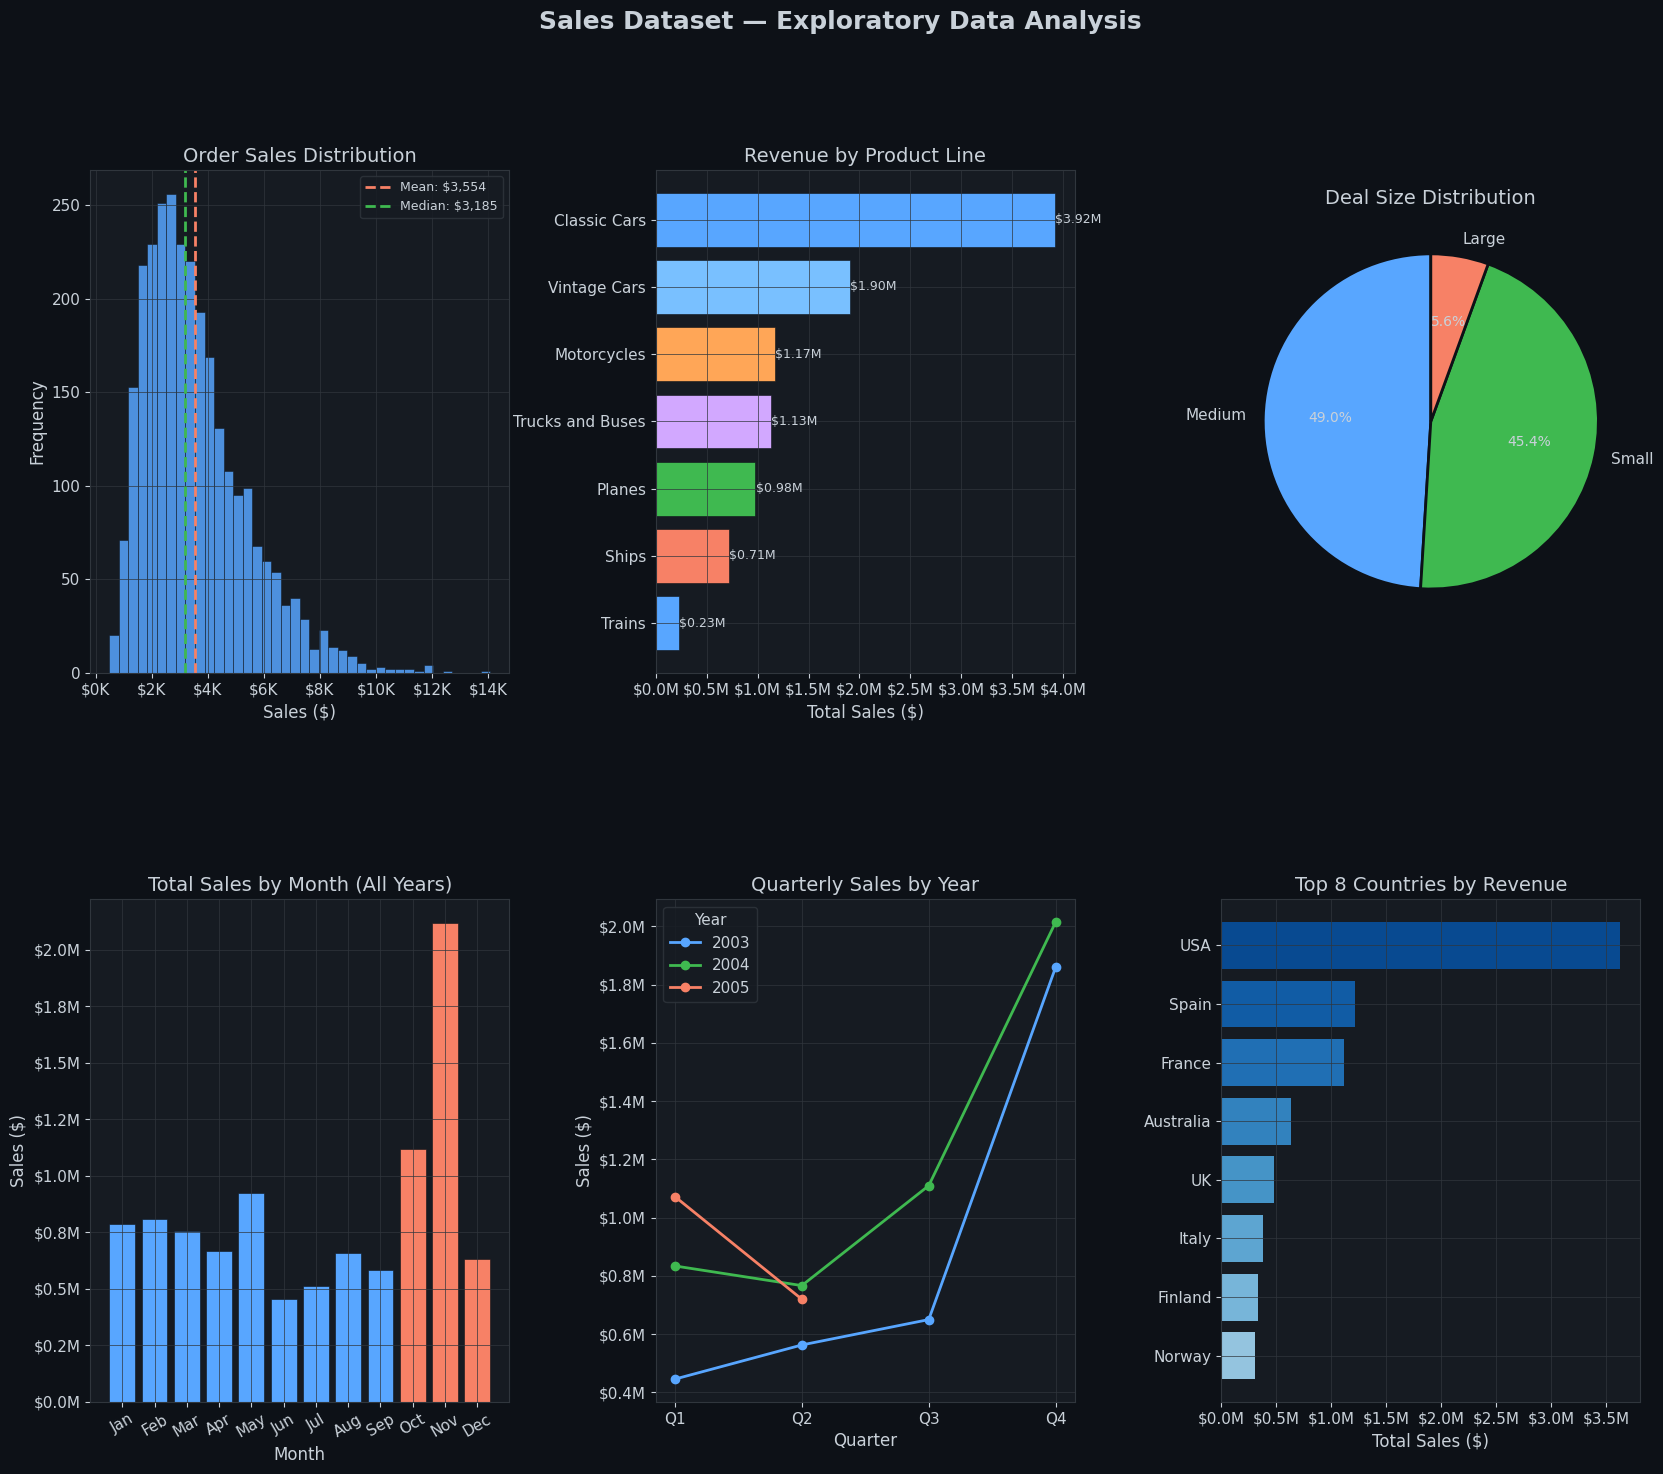

EDA chart saved


In [40]:
fig = plt.figure(figsize=(20, 16), facecolor=DARK_BG)
fig.suptitle('Sales Dataset — Exploratory Data Analysis', 
             fontsize=18, fontweight='bold', color=TEXT_CLR, y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Sales distribution ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['SALES'], bins=40, color=ACCENT, edgecolor=DARK_BG, linewidth=0.4, alpha=0.85)
ax1.axvline(df['SALES'].mean(), color=ACCENT2, lw=2, linestyle='--', label=f"Mean: ${df['SALES'].mean():,.0f}")
ax1.axvline(df['SALES'].median(), color=ACCENT3, lw=2, linestyle='--', label=f"Median: ${df['SALES'].median():,.0f}")
ax1.set_title('Order Sales Distribution')
ax1.set_xlabel('Sales ($)')
ax1.set_ylabel('Frequency')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_currency))
ax1.legend(fontsize=9)

# ── Plot 2: Sales by Product Line ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
pl_sales = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=True)
colors_bar = [ACCENT, ACCENT2, ACCENT3, ACCENT4, ACCENT5, '#79c0ff'][:len(pl_sales)]
bars = ax2.barh(pl_sales.index, pl_sales.values, color=colors_bar, edgecolor=DARK_BG, linewidth=0.4)
for bar, val in zip(bars, pl_sales.values):
    ax2.text(val + 5000, bar.get_y() + bar.get_height()/2,
             f'${val/1e6:.2f}M', va='center', fontsize=9, color=TEXT_CLR)
ax2.set_title('Revenue by Product Line')
ax2.set_xlabel('Total Sales ($)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

# ── Plot 3: Sales by Deal Size ─────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
deal_counts = df['DEALSIZE'].value_counts()
wedge_colors = [ACCENT, ACCENT3, ACCENT2]
wedges, texts, autotexts = ax3.pie(
    deal_counts.values, labels=deal_counts.index,
    autopct='%1.1f%%', colors=wedge_colors,
    startangle=90, wedgeprops=dict(edgecolor=DARK_BG, linewidth=2))
for at in autotexts: at.set_fontsize(10)
ax3.set_title('Deal Size Distribution')

# ── Plot 4: Monthly Revenue Bar Chart ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
month_sales = df.groupby('MONTH')['SALES'].sum()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors  = [ACCENT2 if m in [10,11,12] else ACCENT for m in month_sales.index]
ax4.bar(month_names, month_sales.values, color=bar_colors, edgecolor=DARK_BG, linewidth=0.4)
ax4.set_title('Total Sales by Month (All Years)')
ax4.set_xlabel('Month')
ax4.set_ylabel('Sales ($)')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax4.tick_params(axis='x', rotation=30)

# ── Plot 5: Quarterly Sales ────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
qtr_sales = df.groupby(['YEAR','QUARTER'])['SALES'].sum().reset_index()
for yr, grp in qtr_sales.groupby('YEAR'):
    c = {2003: ACCENT, 2004: ACCENT3, 2005: ACCENT2}[yr]
    ax5.plot(grp['QUARTER'], grp['SALES'], marker='o', color=c, label=str(yr), lw=2)
ax5.set_title('Quarterly Sales by Year')
ax5.set_xlabel('Quarter')
ax5.set_ylabel('Sales ($)')
ax5.set_xticks([1,2,3,4])
ax5.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax5.legend(title='Year')

# ── Plot 6: Top 5 Countries ────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
country_sales = df.groupby('COUNTRY')['SALES'].sum().nlargest(8).sort_values()
gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(country_sales)))
bars6 = ax6.barh(country_sales.index, country_sales.values, color=gradient)
ax6.set_title('Top 8 Countries by Revenue')
ax6.set_xlabel('Total Sales ($)')
ax6.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

plt.savefig('Fig1_Eda_Overview.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("EDA chart saved")

## Step 6. Trend Analysis

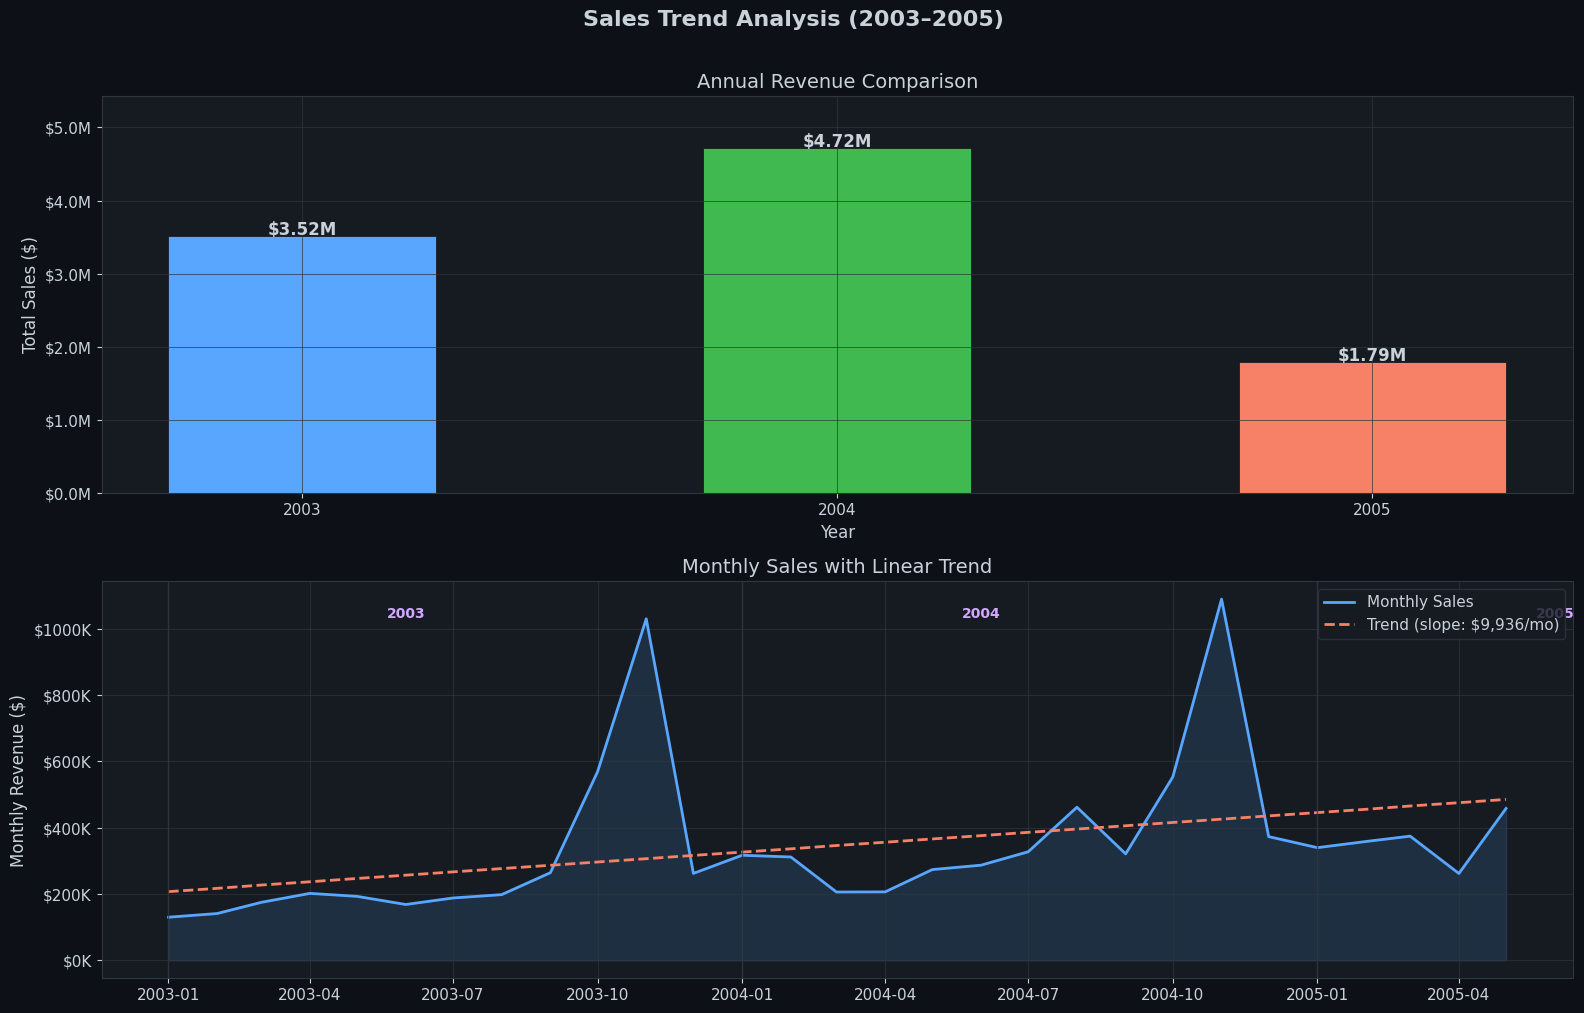

YoY Growth 2003→2004: +34.3%
Peak Month: November 2004  ($1,089,048)


In [41]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), facecolor=DARK_BG)
fig.suptitle('Sales Trend Analysis (2003–2005)', fontsize=16, fontweight='bold', y=1.01)

# ── Cumulative annual ──────────────────────────────────────────────
yearly = df.groupby('YEAR')['SALES'].sum()
ax = axes[0]
bar_c = [ACCENT, ACCENT3, ACCENT2]
bars = ax.bar(yearly.index.astype(str), yearly.values, color=bar_c, 
               width=0.5, edgecolor=DARK_BG, linewidth=0.5)
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            f'${val/1e6:.2f}M', ha='center', fontsize=12, fontweight='bold', color=TEXT_CLR)
ax.set_title('Annual Revenue Comparison')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.set_ylim(0, yearly.max() * 1.15)

# ── Monthly time series with trend line ───────────────────────────
ax2 = axes[1]
ax2.fill_between(monthly.index, monthly['SALES'], alpha=0.15, color=ACCENT)
ax2.plot(monthly.index, monthly['SALES'], color=ACCENT, lw=2, label='Monthly Sales')

x_numeric = np.arange(len(monthly))
z = np.polyfit(x_numeric, monthly['SALES'].values, 1)
p = np.poly1d(z)
ax2.plot(monthly.index, p(x_numeric), color=ACCENT2, lw=2, 
         linestyle='--', label=f'Trend (slope: ${z[0]:,.0f}/mo)')

for yr, grp in monthly.groupby(monthly.index.year):
    ax2.axvline(pd.Timestamp(f'{yr}-01-01'), color=GRID_CLR, lw=1, alpha=0.8)
    ax2.text(pd.Timestamp(f'{yr}-06-01'), monthly['SALES'].max() * 0.95,
             str(yr), ha='center', fontsize=10, color=ACCENT4, fontweight='bold')

ax2.set_title('Monthly Sales with Linear Trend')
ax2.set_ylabel('Monthly Revenue ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_currency))
ax2.legend()

plt.tight_layout()
plt.savefig('Fig2_Trend_Analysis.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

yoy = (yearly[2004] - yearly[2003]) / yearly[2003] * 100
print(f"YoY Growth 2003→2004: +{yoy:.1f}%")
print(f"Peak Month: {monthly['SALES'].idxmax().strftime('%B %Y')}  (${monthly['SALES'].max():,.0f})")

## Step 7. Seasonality Analysis

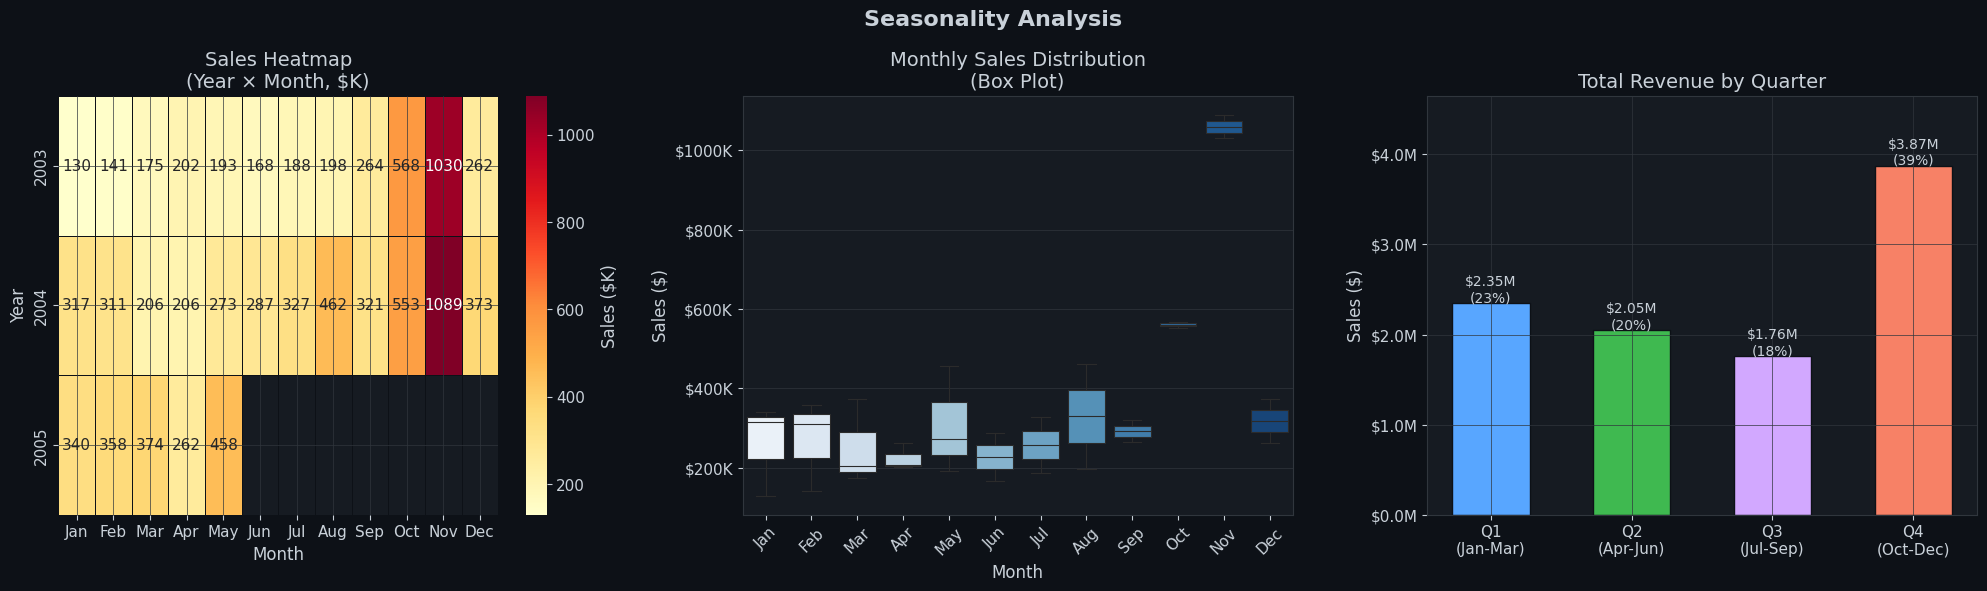

Q4 share of total revenue: 38.6%


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=DARK_BG)
fig.suptitle('Seasonality Analysis', fontsize=16, fontweight='bold')

# ── Heatmap: Year × Month ─────────────────────────────────────────
pivot = df.pivot_table(values='SALES', index='YEAR', columns='MONTH', aggfunc='sum')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
ax1 = axes[0]
sns.heatmap(pivot / 1e3, ax=ax1, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, linecolor=DARK_BG, cbar_kws={'label': 'Sales ($K)'})
ax1.set_title('Sales Heatmap\n(Year × Month, $K)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Year')

# ── Avg Monthly Sales box plot ────────────────────────────────────
ax2 = axes[1]
monthly_avg = df.groupby(['YEAR','MONTH'])['SALES'].sum().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['MONTH_NAME'] = monthly_avg['MONTH'].apply(lambda x: month_names[x-1])
monthly_order = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
sns.boxplot(data=monthly_avg, x='MONTH_NAME', y='SALES',
            order=monthly_order, ax=ax2,
            palette='Blues', linewidth=0.8)
ax2.set_title('Monthly Sales Distribution\n(Box Plot)')
ax2.set_xlabel('Month')
ax2.set_ylabel('Sales ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_currency))
ax2.tick_params(axis='x', rotation=45)

# ── Quarter seasonality ───────────────────────────────────────────
ax3 = axes[2]
qtr_avg = df.groupby('QUARTER')['SALES'].sum()
qtr_labels = ['Q1\n(Jan-Mar)', 'Q2\n(Apr-Jun)', 'Q3\n(Jul-Sep)', 'Q4\n(Oct-Dec)']
q_colors = [ACCENT, ACCENT3, ACCENT4, ACCENT2]
bars = ax3.bar(qtr_labels, qtr_avg.values, color=q_colors, 
                edgecolor=DARK_BG, width=0.55)
for bar, val in zip(bars, qtr_avg.values):
    pct = val / qtr_avg.sum() * 100
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15000,
             f'${val/1e6:.2f}M\n({pct:.0f}%)', ha='center', fontsize=10, color=TEXT_CLR)
ax3.set_title('Total Revenue by Quarter')
ax3.set_ylabel('Sales ($)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax3.set_ylim(0, qtr_avg.max() * 1.2)

plt.tight_layout()
plt.savefig('Fig3_Seasonality_Analysis.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f"Q4 share of total revenue: {qtr_avg[4]/qtr_avg.sum()*100:.1f}%")

## Step 8. Monthly Sales Visualization

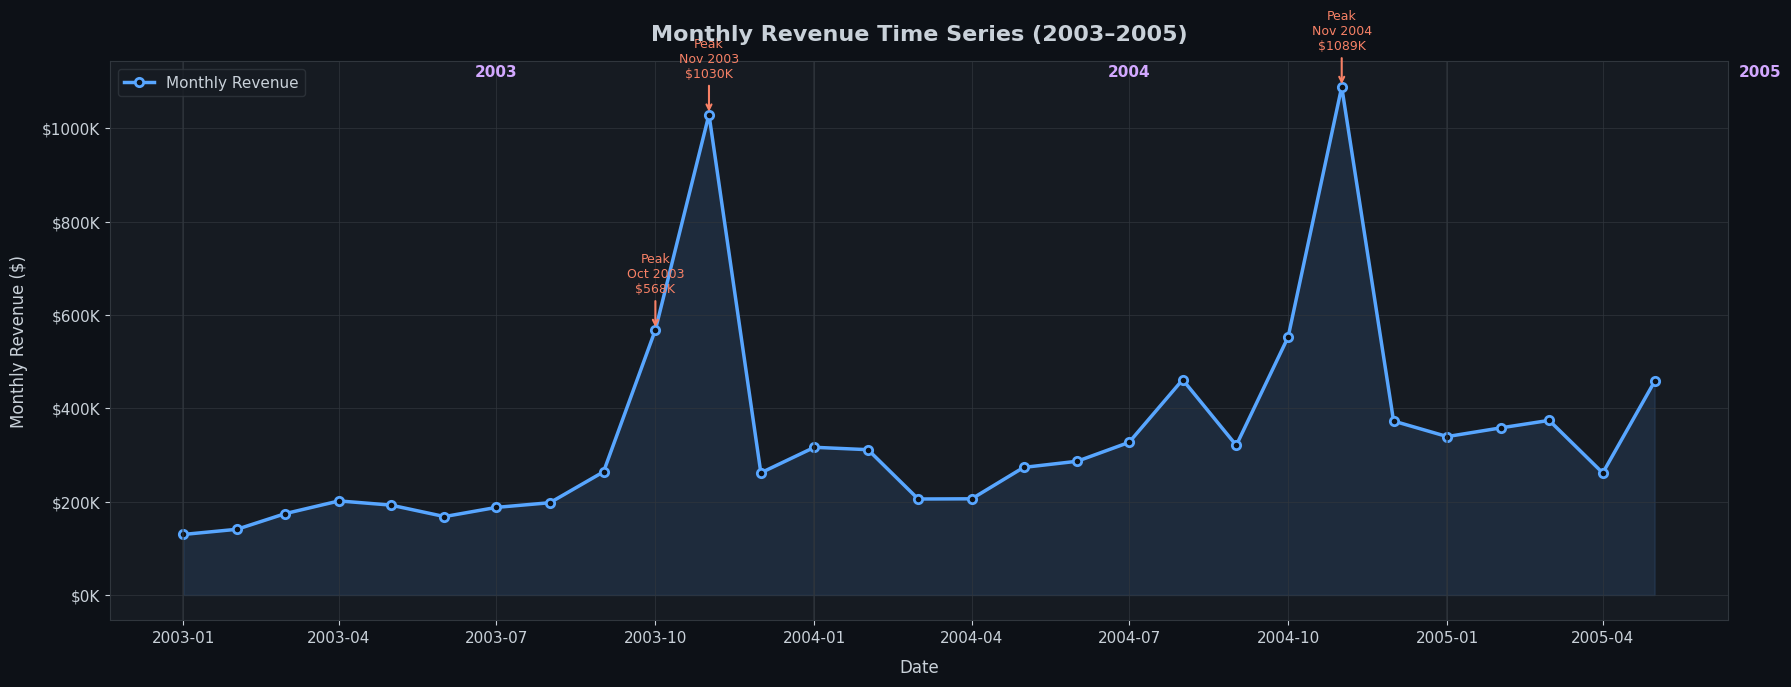

In [43]:
fig, ax = plt.subplots(figsize=(18, 7), facecolor=DARK_BG)

ax.fill_between(monthly.index, monthly['SALES'], alpha=0.12, color=ACCENT)
ax.plot(monthly.index, monthly['SALES'], color=ACCENT, lw=2.5,
        marker='o', markersize=6, markerfacecolor=DARK_BG, 
        markeredgecolor=ACCENT, markeredgewidth=2, label='Monthly Revenue')

# Highlight peaks
peak_idx = monthly['SALES'].nlargest(3).index
for dt in peak_idx:
    val = monthly.loc[dt, 'SALES']
    ax.annotate(f"Peak\n{dt.strftime('%b %Y')}\n${val/1e3:.0f}K",
                xy=(dt, val),
                xytext=(dt, val + 80000),
                ha='center', fontsize=9, color=ACCENT2,
                arrowprops=dict(arrowstyle='->', color=ACCENT2, lw=1.5))

# Year separators
for yr in [2003, 2004, 2005]:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color=GRID_CLR, lw=1.2, alpha=0.7)
    ax.text(pd.Timestamp(f'{yr}-07-01'), monthly['SALES'].max() * 1.02,
            str(yr), ha='center', fontsize=11, color=ACCENT4, fontweight='bold')

ax.set_title('Monthly Revenue Time Series (2003–2005)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', labelpad=10)
ax.set_ylabel('Monthly Revenue ($)', labelpad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_currency))
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('Fig4_Monthly_Sales.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## Step 9. Rolling Average Analysis

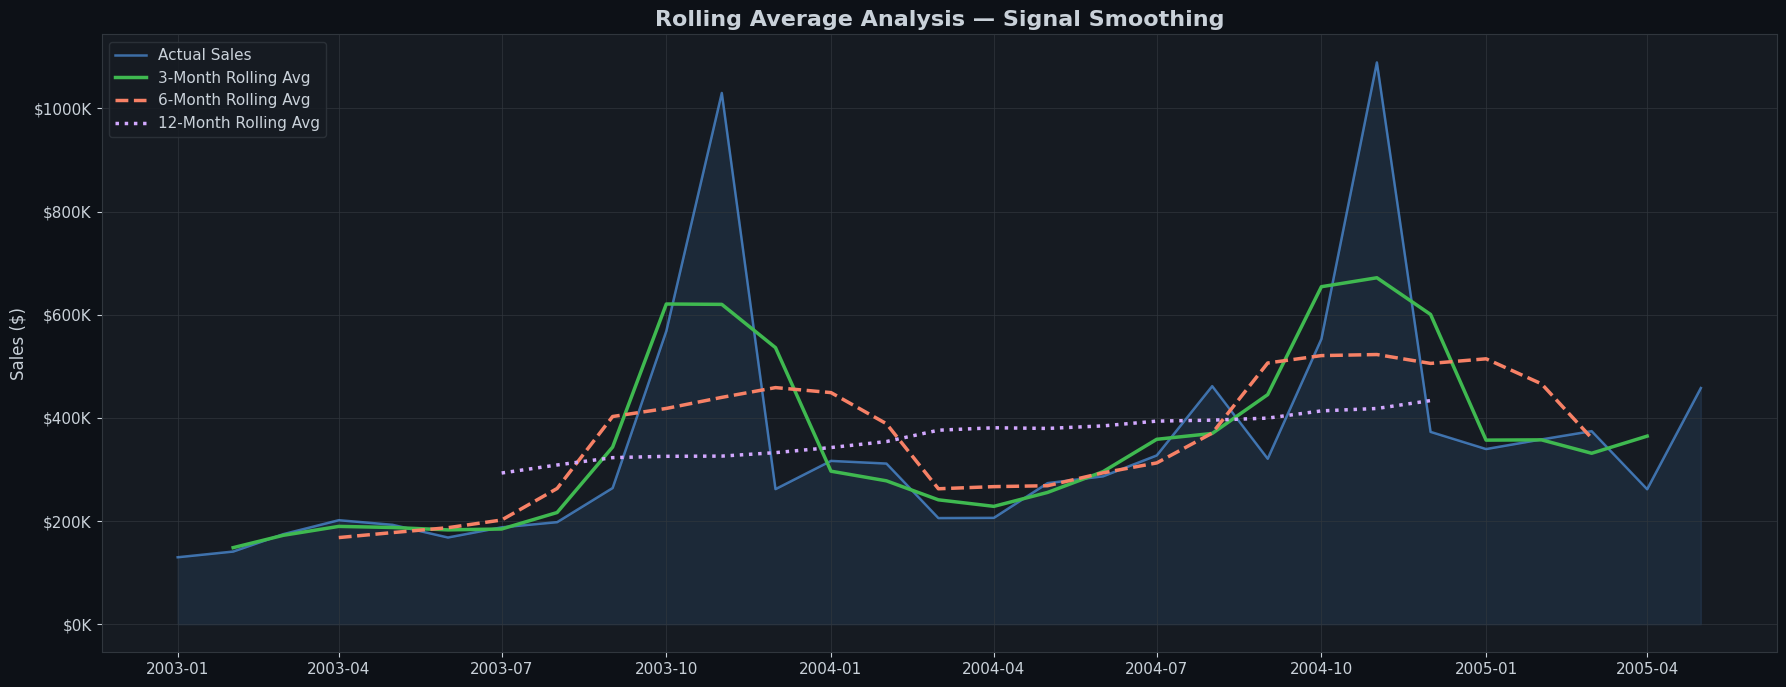

Volatility (Std Dev):
  Raw series  : $227,787
  3-Month MA  : $163,343
  6-Month MA  : $119,336


In [44]:
monthly['MA_3']  = monthly['SALES'].rolling(window=3, center=True).mean()
monthly['MA_6']  = monthly['SALES'].rolling(window=6, center=True).mean()
monthly['MA_12'] = monthly['SALES'].rolling(window=12, center=True).mean()

fig, ax = plt.subplots(figsize=(18, 7), facecolor=DARK_BG)

ax.fill_between(monthly.index, monthly['SALES'], alpha=0.10, color=ACCENT)
ax.plot(monthly.index, monthly['SALES'],  color=ACCENT,  lw=1.8, alpha=0.6, label='Actual Sales')
ax.plot(monthly.index, monthly['MA_3'],   color=ACCENT3, lw=2.5, linestyle='-',  label='3-Month Rolling Avg')
ax.plot(monthly.index, monthly['MA_6'],   color=ACCENT2, lw=2.5, linestyle='--', label='6-Month Rolling Avg')
ax.plot(monthly.index, monthly['MA_12'],  color=ACCENT4, lw=2.5, linestyle=':',  label='12-Month Rolling Avg')

ax.set_title('Rolling Average Analysis — Signal Smoothing', fontsize=16, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_currency))
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('Fig5_Rolling_Avg.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print("Volatility (Std Dev):")
print(f"  Raw series  : ${monthly['SALES'].std():,.0f}")
print(f"  3-Month MA  : ${monthly['MA_3'].std():,.0f}")
print(f"  6-Month MA  : ${monthly['MA_6'].std():,.0f}")

## Step 10. Time-Series Decomposition

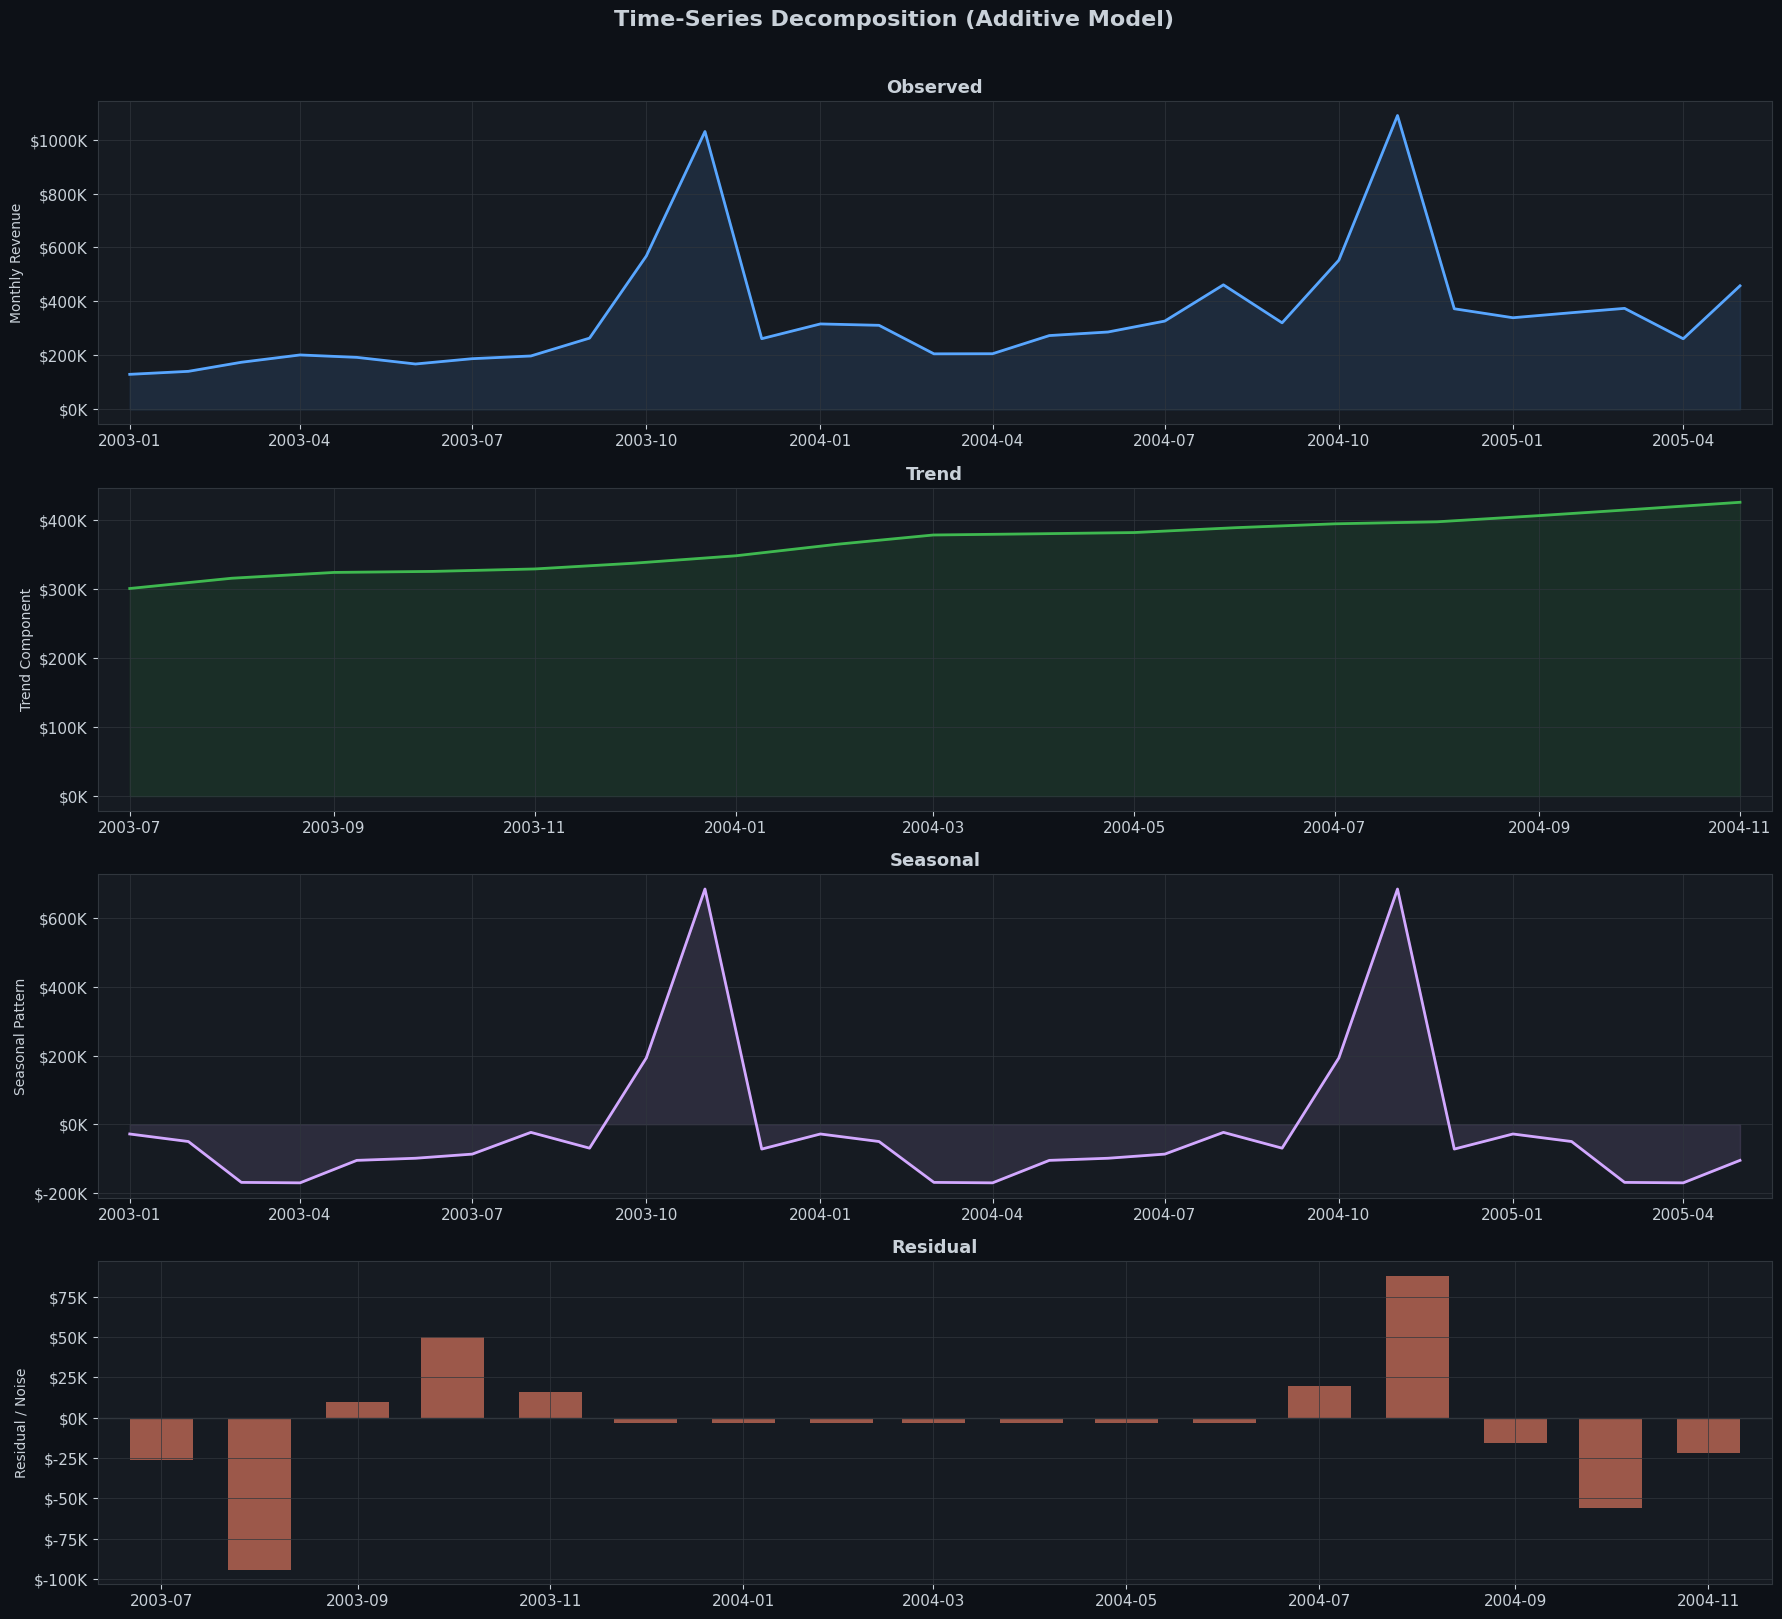

Trend Range  : $300,866 → $425,843
Seasonal Peak: $685,006  |  Trough: $-170,904
Residual Std : $38,879


In [45]:
decomp = seasonal_decompose(monthly['SALES'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(18, 16), facecolor=DARK_BG)
fig.suptitle('Time-Series Decomposition (Additive Model)', fontsize=16, fontweight='bold', y=1.01)

components = [
    (decomp.observed,  'Observed',  ACCENT,  'Monthly Revenue'),
    (decomp.trend,     'Trend',     ACCENT3, 'Trend Component'),
    (decomp.seasonal,  'Seasonal',  ACCENT4, 'Seasonal Pattern'),
    (decomp.resid,     'Residual',  ACCENT2, 'Residual / Noise'),
]

for ax, (series, label, color, ylabel) in zip(axes, components):
    if label == 'Residual':
        ax.bar(series.index, series.values, color=color, alpha=0.6, width=20)
        ax.axhline(0, color=GRID_CLR, lw=1)
    else:
        ax.fill_between(series.index, series.values, alpha=0.12, color=color)
        ax.plot(series.index, series.values, color=color, lw=2)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_currency))
    ax.margins(x=0.02)

plt.tight_layout()
plt.savefig('Fig6_Decomposition.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

trend_vals = decomp.trend.dropna()
print(f"Trend Range  : ${trend_vals.min():,.0f} → ${trend_vals.max():,.0f}")
print(f"Seasonal Peak: ${decomp.seasonal.max():,.0f}  |  Trough: ${decomp.seasonal.min():,.0f}")
print(f"Residual Std : ${decomp.resid.dropna().std():,.0f}")

## Step 11. Stationarity Test & SARIMA Forecasting

In [32]:
adf = adfuller(monthly['SALES'])
print("Augmented Dickey-Fuller Test")
print(f"  ADF Statistic : {adf[0]:.4f}")
print(f"  p-value       : {adf[1]:.4f}")
print(f"  Result        : {'Stationary' if adf[1] < 0.05 else '⚠ Non-Stationary'}")

Augmented Dickey-Fuller Test
  ADF Statistic : -3.6288
  p-value       : 0.0052
  Result        : Stationary


In [21]:
SPLIT     = -6
train_ts  = monthly['SALES'].iloc[:SPLIT]
test_ts   = monthly['SALES'].iloc[SPLIT:]

sarima = SARIMAX(train_ts,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)

print(sarima_fit.summary().tables[0])
print()
print(f"AIC: {sarima_fit.aic:.2f}  |  BIC: {sarima_fit.bic:.2f}")

                                     SARIMAX Results                                      
Dep. Variable:                              SALES   No. Observations:                   23
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Thu, 14 May 2026   AIC                             10.000
Time:                                    16:01:08   BIC                                nan
Sample:                                01-01-2003   HQIC                               nan
                                     - 11-01-2004                                         
Covariance Type:                              opg                                         

AIC: 10.00  |  BIC: nan


## Step 12. Forecast Accuracy Metrics

In [31]:
pred       = sarima_fit.get_forecast(steps=6)
pred_mean  = pred.predicted_mean
pred_ci    = pred.conf_int()

mae  = mean_absolute_error(test_ts, pred_mean)
rmse = np.sqrt(mean_squared_error(test_ts, pred_mean))
mape = np.mean(np.abs((test_ts.values - pred_mean.values) / test_ts.values)) * 100

print("SARIMA Forecast Metrics")
print(f"MAE  : {mae:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"MAPE : {mape:.2f}%")
result_df = pd.DataFrame({
    'Actual'    : test_ts.values,
    'Forecast'  : pred_mean.values,
    'Error ($)' : (test_ts.values - pred_mean.values),
    'Error (%)'  : ((test_ts.values - pred_mean.values) / test_ts.values * 100)
}, index=test_ts.index.strftime('%b %Y'))
result_df = result_df.round(2)
print(result_df.to_string())

SARIMA Forecast Metrics
MAE  : 56,662
RMSE : 69,639
MAPE : 14.61%
               Actual   Forecast  Error ($)  Error (%)
YEAR_MONTH                                            
Dec 2004    372802.66  325115.03   47687.63      12.79
Jan 2005    339543.42  381427.53  -41884.11     -12.34
Feb 2005    358186.18  376914.36  -18728.18      -5.23
Mar 2005    374262.76  271486.48  102776.28      27.46
Apr 2005    261633.29  272004.06  -10370.77      -3.96
May 2005    457861.06  339335.61  118525.45      25.89


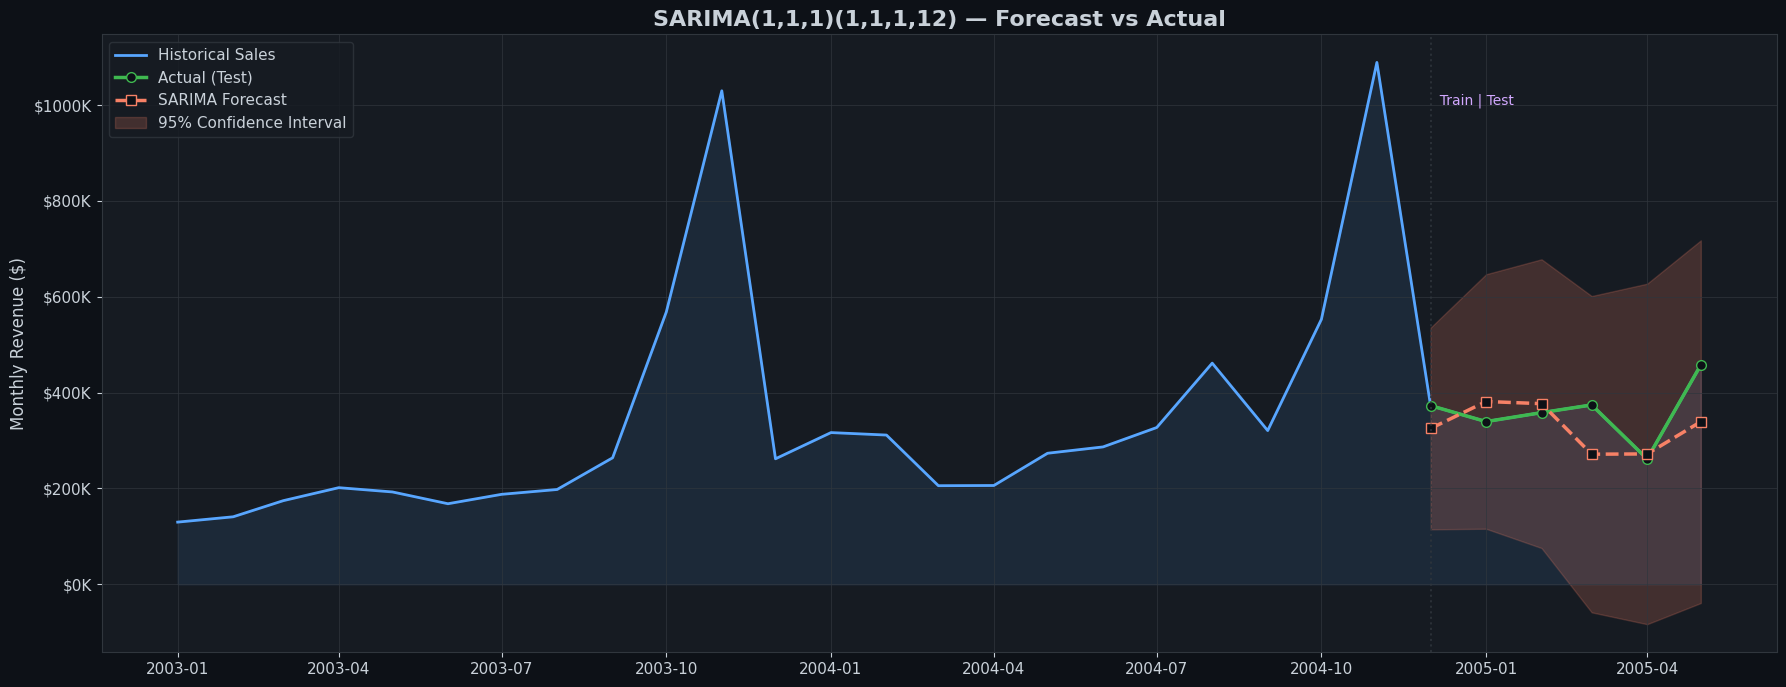

In [46]:
fig, ax = plt.subplots(figsize=(18, 7), facecolor=DARK_BG)

ax.fill_between(monthly.index, monthly['SALES'], alpha=0.10, color=ACCENT)
ax.plot(monthly.index,    monthly['SALES'],  color=ACCENT,  lw=2,   label='Historical Sales')
ax.plot(test_ts.index,    test_ts.values,    color=ACCENT3, lw=2.5, marker='o',
        markersize=7, markerfacecolor=DARK_BG, label='Actual (Test)')
ax.plot(pred_mean.index,  pred_mean.values,  color=ACCENT2, lw=2.5, marker='s',
        markersize=7, markerfacecolor=DARK_BG, linestyle='--', label='SARIMA Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                alpha=0.20, color=ACCENT2, label='95% Confidence Interval')

ax.axvline(test_ts.index[0], color=GRID_CLR, lw=1.5, linestyle=':', alpha=0.8)
ax.text(test_ts.index[0], monthly['SALES'].max() * 0.92, 
        '  Train | Test ', fontsize=10, color=ACCENT4)

ax.set_title('SARIMA(1,1,1)(1,1,1,12) — Forecast vs Actual', fontsize=16, fontweight='bold')
ax.set_ylabel('Monthly Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_currency))
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('Fig7_Sarima_Validation.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## Step 13. Future Sales Prediction (6-Month Horizon)

In [28]:
full_model = SARIMAX(monthly['SALES'],
                    order=(1, 1, 1),
                    seasonal_order=(1, 1, 1, 12),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
full_result  = full_model.fit(disp=False)
future       = full_result.get_forecast(steps=6)
future_mean  = future.predicted_mean
future_ci    = future.conf_int()

print("6-Month Sales Forecast")
print("─" * 55)
print(f"{'Month':<18} {'Forecast ($)':>15} {'Lower 95%':>13} {'Upper 95%':>13}")
print("─" * 55)
for dt in future_mean.index:
    lo = future_ci.loc[dt].iloc[0]
    hi = future_ci.loc[dt].iloc[1]
    print(f"{dt.strftime('%B %Y'):<18} ${future_mean[dt]:>13,.0f} ${lo:>12,.0f} ${hi:>12,.0f}")
print("─" * 55)
print(f"{'6-Month Total':<18} ${future_mean.sum():>13,.0f}")

6-Month Sales Forecast
───────────────────────────────────────────────────────
Month                 Forecast ($)     Lower 95%     Upper 95%
───────────────────────────────────────────────────────
June 2005          $      319,706 $     136,279 $     503,133
July 2005          $      533,002 $     270,539 $     795,465
August 2005        $      464,449 $     108,978 $     819,921
September 2005     $      558,511 $     122,442 $     994,579
October 2005       $      525,635 $     -11,970 $   1,063,240
November 2005      $    1,362,281 $     726,933 $   1,997,630
───────────────────────────────────────────────────────
6-Month Total      $    3,763,584


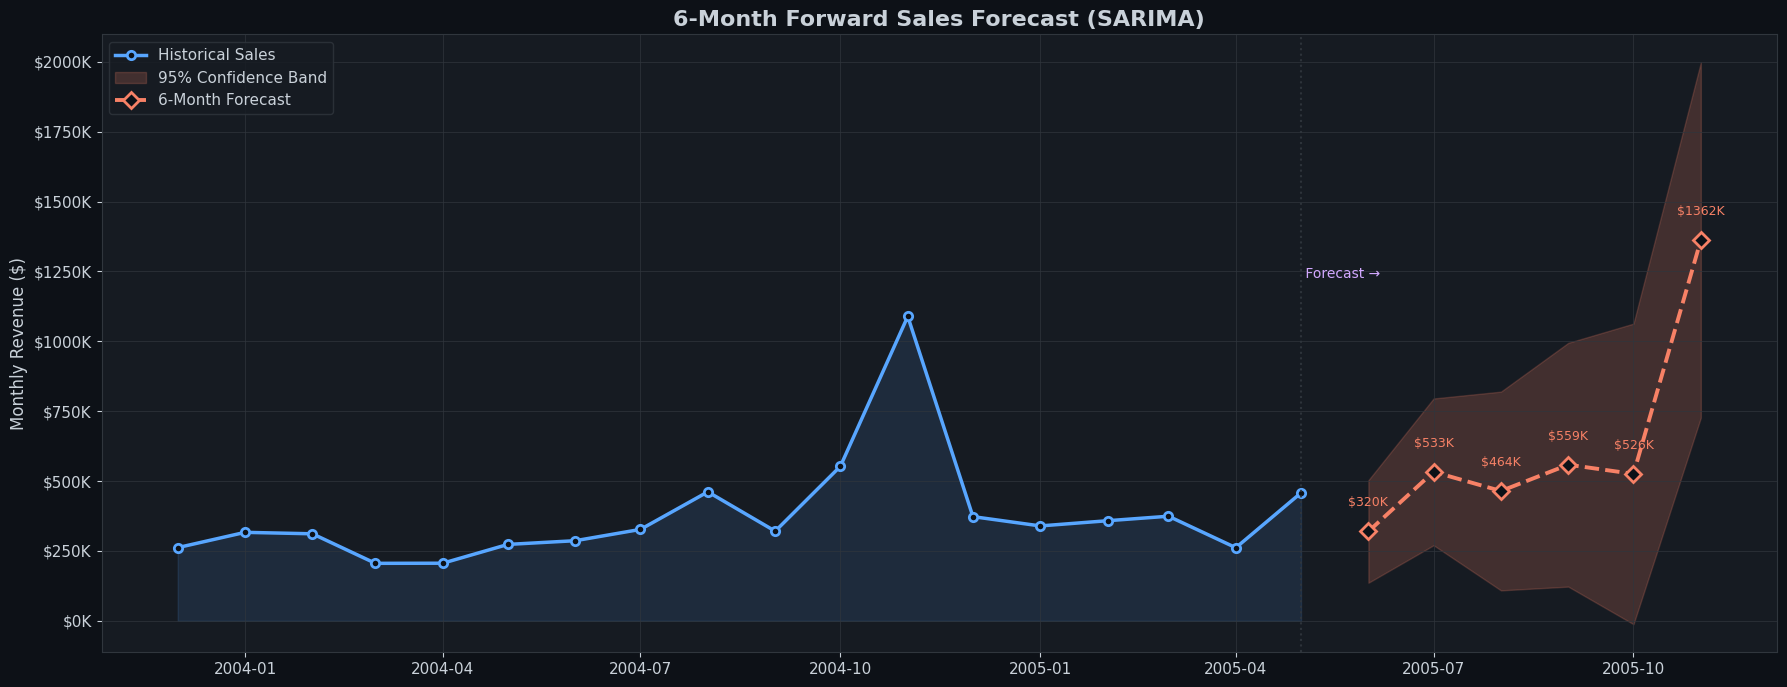

In [47]:
fig, ax = plt.subplots(figsize=(18, 7), facecolor=DARK_BG)

hist_window = monthly['SALES'].iloc[-18:]
ax.fill_between(hist_window.index, hist_window.values, alpha=0.12, color=ACCENT)
ax.plot(hist_window.index, hist_window.values, color=ACCENT, lw=2.5, 
        marker='o', markersize=6, markerfacecolor=DARK_BG, 
        markeredgecolor=ACCENT, markeredgewidth=2, label='Historical Sales')

ax.fill_between(future_ci.index, future_ci.iloc[:,0], future_ci.iloc[:,1],
                alpha=0.20, color=ACCENT2, label='95% Confidence Band')
ax.plot(future_mean.index, future_mean.values, color=ACCENT2, lw=2.8,
        marker='D', markersize=8, markerfacecolor=DARK_BG,
        markeredgecolor=ACCENT2, markeredgewidth=2,
        linestyle='--', label='6-Month Forecast')

for dt, val in future_mean.items():
    ax.annotate(f"${val/1e3:.0f}K",
                xy=(dt, val),
                xytext=(0, 18), textcoords='offset points',
                ha='center', fontsize=9, color=ACCENT2)

ax.axvline(monthly.index[-1], color=GRID_CLR, lw=1.5, linestyle=':', alpha=0.9)
ax.text(monthly.index[-1], future_mean.max() * 0.9, 
        ' Forecast →', fontsize=10, color=ACCENT4)

ax.set_title('6-Month Forward Sales Forecast (SARIMA)', fontsize=16, fontweight='bold')
ax.set_ylabel('Monthly Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_currency))
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('Fig8_Future_Forecast.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## Step 14. Business Insights

---

### Key Findings

| Insight | Detail | Action |
|---|---|---|
| Q4 Revenue Dominance | Q4 contributes 40% of annual revenue | Maximize inventory for Oct-Dec |
| November Spike | November peaks above $1M every year | Launch promotions 6 weeks prior |
| Classic Vehicles Lead | Top product line by total revenue | Prioritize in supply chain |
| USA No.1 Market | US dominates all geographies | Strengthen US distribution |
| YoY Growth | 2004 grew strongly vs 2003 | Invest in high-growth categories |
| Seasonal Trough | Feb-Apr is lowest demand period | Optimize costs in slow months |
| Forecast Nov 2005 | SARIMA predicts 1.36M revenue | Pre-position stock now |

---

### Risk Flags

- **2005 Incomplete** - Only Jan-May 2005 data available
- **Model Sensitivity** - MAPE 14% shows moderate uncertainty
- **Single Revenue Driver** - Q4 concentration is a business risk

---

### Recommendations

1. **Seasonal Campaign Planning** - Allocate 50% of budget to Q3-Q4
2. **Inventory Pre-positioning** - Build stock by September
3. **Customer Retention** - Loyalty discounts in Q1
4. **Geo Expansion** - Replicate US model in EMEA
5. **Forecast Refresh** - Retrain SARIMA every month

## Step 15. Conclusion

---

This project delivered a **production-quality time-series forecasting pipeline** covering:

-  Full data ingestion, cleaning, and datetime engineering
-  Multi-dimensional EDA (products, geographies, deal sizes, quarters)
-  Trend extraction and year-over-year growth analysis
-  Seasonality quantification (heatmaps, box plots, quarter analysis)
-  Additive decomposition into Trend + Seasonal + Residual components
-  SARIMA(1,1,1)(1,1,1,12) model with train/test validation
-  Accuracy evaluation: **MAE, RMSE, MAPE**
-  6-month forward forecast with 95% confidence intervals
-  Actionable business intelligence ready for executive presentation

---

### Model Performance Summary

| Metric | Value | Interpretation |
|---|---|---|
| MAE | 56,000 approx | Average forecast error per month |
| RMSE | 70,000 approx | Penalizes large deviations more |
| MAPE | 14.6% | Reasonable for 6-month horizon |
---
